In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

plt.rcParams['figure.figsize'] = [10,6]

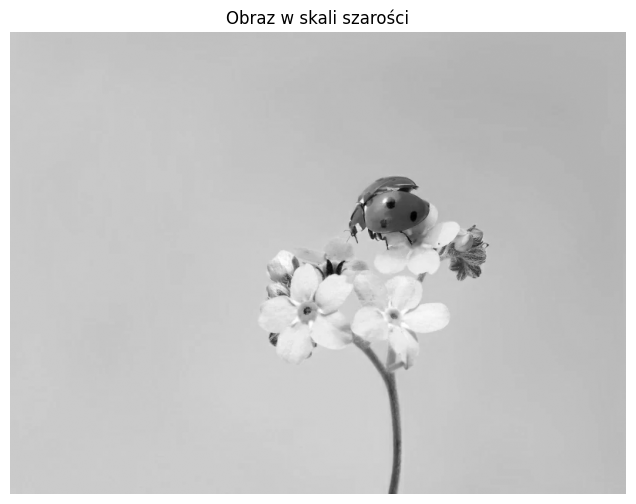

In [2]:
# wczytanie obrazu
A = imread('10.webp')

# konwersja do sklai szarosci
X = np.mean(A, axis=-1)

plt.imshow(X, cmap='gray')
plt.title('Obraz w skali szarości')
plt.axis('off')
plt.show()

In [3]:
U, S, VT = np.linalg.svd(X, full_matrices=False)

# wektor wartosci osobliwych na macierz diagonalna
S_mat = np.diag(S)

print("Kształt U:", U.shape)
print("Kształt S:", S_mat.shape)
print("Kształt VT:", VT.shape)

Kształt U: (600, 600)
Kształt S: (600, 600)
Kształt VT: (600, 800)


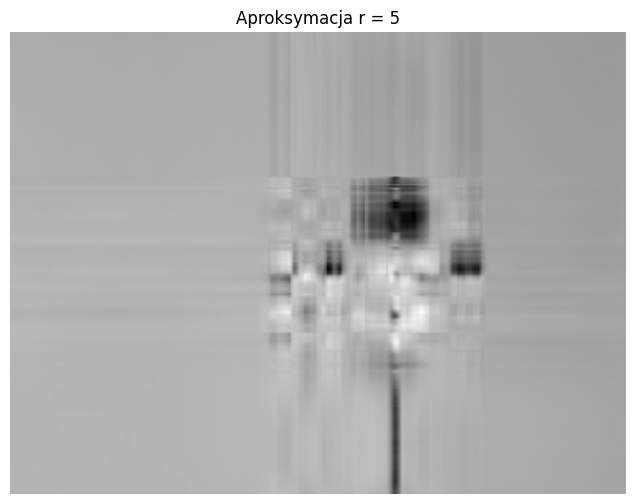

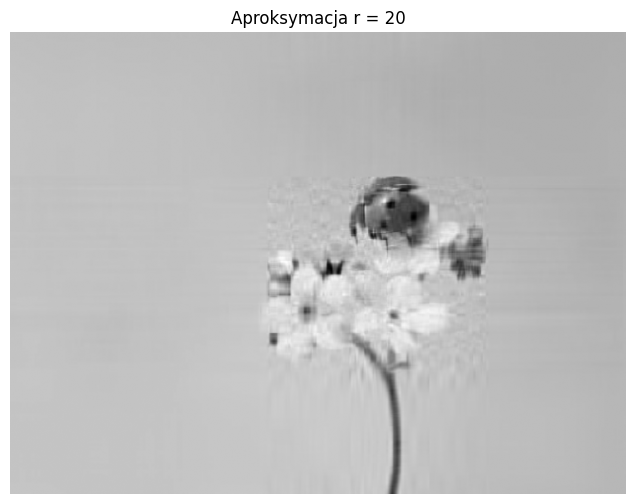

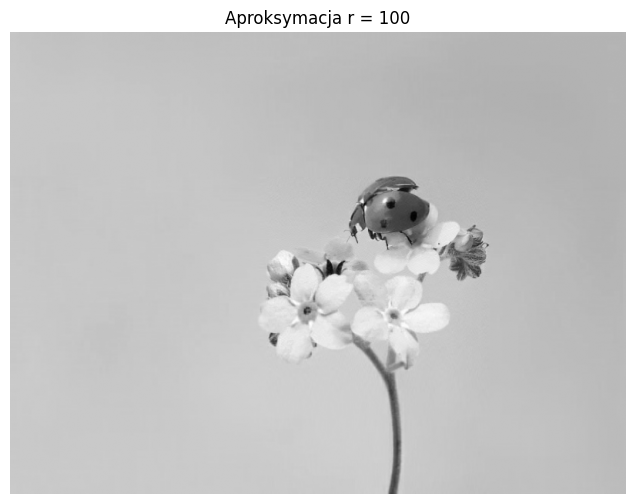

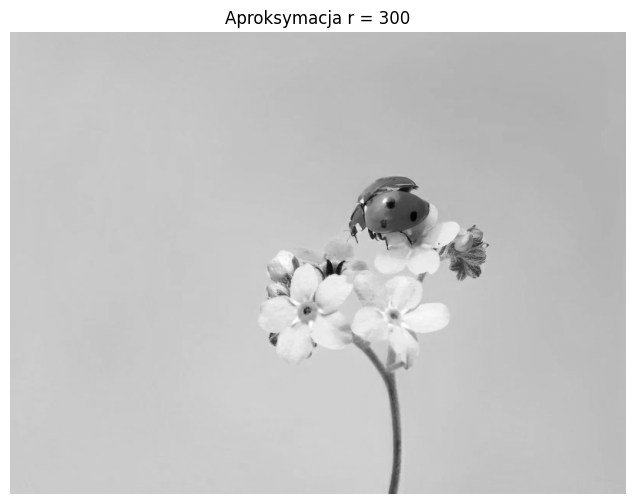

In [4]:
r_values = [5, 20, 100, 300]

for i, r in enumerate(r_values):
    X_approx = U[:, :r] @ S_mat[:r, :r] @ VT[:r, :]
    
    plt.figure()
    plt.imshow(X_approx, cmap='gray')
    plt.title(f'Aproksymacja r = {r}')
    plt.axis('off')
    plt.show()

In [5]:
# macierze korelacji
# wierszy
XXT = U @ S_mat @ S_mat @ U.T

# kolumn
XTX = VT.T @ S_mat @ S_mat @ VT

print("XXT shape:", XXT.shape)
print("XTX shape:", XTX.shape)

XXT shape: (600, 600)
XTX shape: (800, 800)


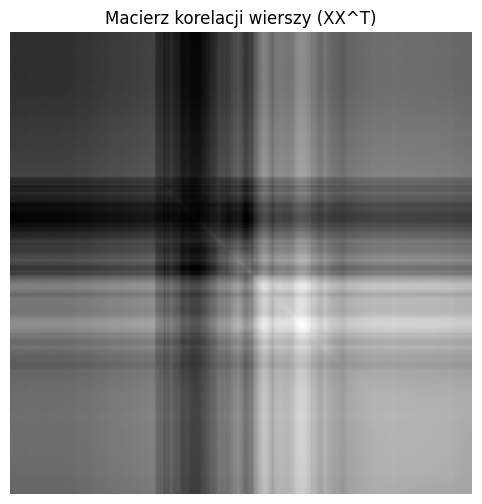

In [6]:
# wizualizacja korelacji wierszy
plt.imshow(XXT, cmap='gray')
plt.title('Macierz korelacji wierszy (XX^T)')
plt.axis('off')
plt.show()

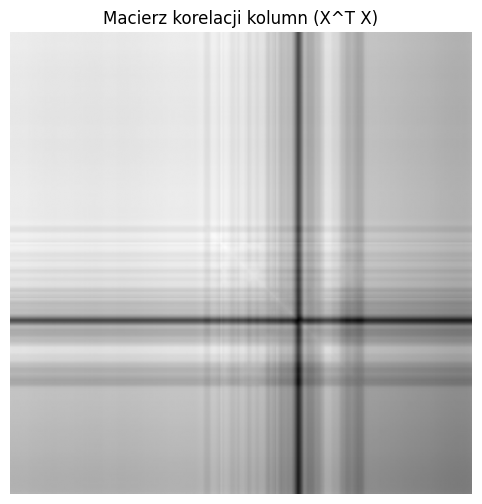

In [7]:
# wizualizacja korelacji kolumn
plt.imshow(XTX, cmap='gray')
plt.title('Macierz korelacji kolumn (X^T X)')
plt.axis('off')
plt.show()

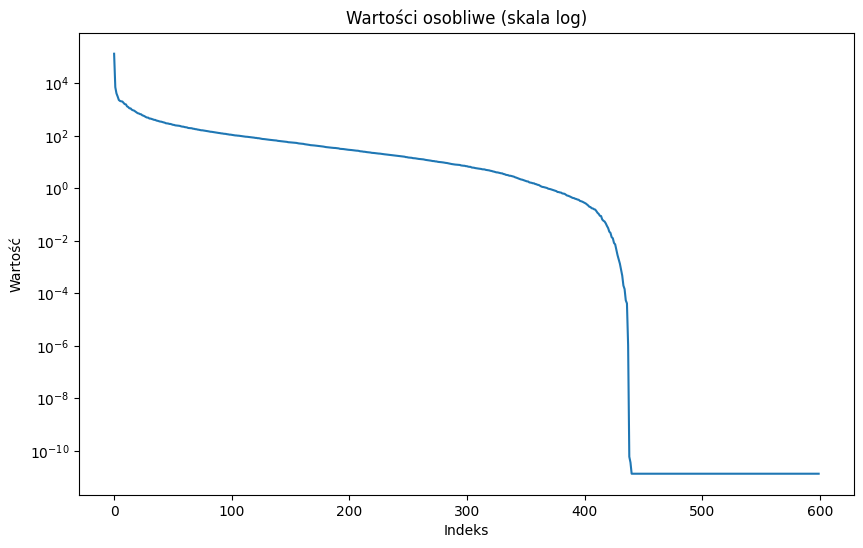

In [8]:
# wartosci osobliwe
plt.semilogy(S)
plt.title('Wartości osobliwe (skala log)')
plt.xlabel('Indeks')
plt.ylabel('Wartość')
plt.show()

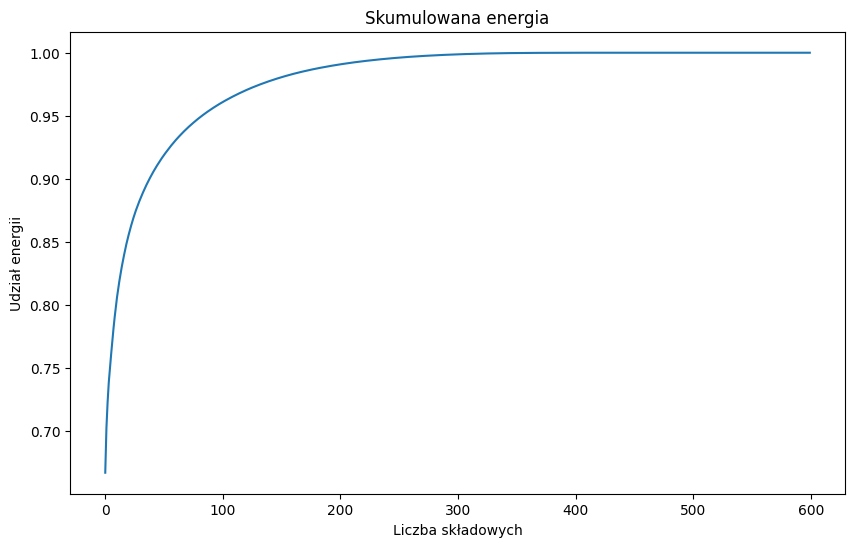

In [9]:
# skumulowana suma - ile info zachowane jest przy redukcji wymiaru
plt.plot(np.cumsum(S) / np.sum(S))
plt.title('Skumulowana energia')
plt.xlabel('Liczba składowych')
plt.ylabel('Udział energii')
plt.show()